<a href="https://colab.research.google.com/github/princebunkcy/About_me/blob/main/NLP_BBC_transformer_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NLP Case Study: BBC News Article Pipeline

This project demonstrates a complete NLP pipeline built on the BBC full-text news dataset. Using state-of-the-art transformer models, I introudced classification,handled subcategory detection, named entity recognition (NER), and summarization.
The end-to-end NLP pipeline applied to BBC news articles, using modern transformer-based models for:

 **Main category classification (fine-tuned BERT)**

 **Subcategory classification (zero-shot learning with BART)**

 **Named Entity Recognition (NER) and profession inference**

 **Event summarization (with BART)**
 **Evaluation using BERTScore and ROUGE**

- # Problem Statement

  News data is unstructured and massive. This project simulates how NLP can turn large-scale text into structured insights for governance, archiving, and public services.

- What methods were used?  
  - Fine-tuning a transformer (`distilbert-base-uncased`) for main category classification
  - Zero-shot classification using facebook/bart-large-mnli for subcategories
  - NER with keyword matching and regex-based profession inference
  - Text summarization with facebook/bart-large-cnn
## Data & Preprocessing
- Zip Converted into a clean CSV file
- Source: BBC full-text dataset (5 main categories: business, entertainment, politics, sport, tech)
- Preprocessing:
  - Removed URLs, special characters, and excessive whitespace
  - Normalized text encoding
  

---

## 3. 🧠 Approach

| Component        | Technique / Model Used                  | Reasoning |
|------------------|------------------------------------------|-----------|
| Main Classifier | distilbert-base-uncased fine-tuned   | Lightweight transformer for text classification |
| Subcategories   | facebook/bart-large-mnli (zero-shot) | No labeled data needed for subtopics |
| NER + Job Inference | spaCy (en_core_web_trf) + regex inference| Extract persons and infer roles (e.g., Politician, Musician)|
| Summarization | facebook/bart-large-cnn| Condense news articles to core events |

---

## 4. Results

- Main classifier performance:
  - Accuracy: ~99%
  - F1 Score (macro): ~0.99
  - Categories: balanced performance across business, sport, tech, etc.

- Subcategory classification:

  Used only label prompts and raw text.
  Correctly assigned examples like football, economic policy, literature, and AI

- NER + job inference:

  Inferred jobs like Politician, Athlete, Writer using context-based keyword matching
   - Accuracy: ~86%
  - F1 Score (macro): ~0.82

- Summarization:
  - Summarized April events from longer articles with relevant output using BART.

  - F1 Score (macro): ~0.85

---

## 5. Conclusion

- Built a modular NLP pipeline that can process, classify, and interpret raw news articles.
- Used generative, zero-shot, and fine-tuned models effectively.
- Future work:
  - Improve job-role extraction with co-reference resolution
  - Fine-tune subcategory models for more accuracy
  - Extraction to filter events beyond April


NLP Case Study: BBC News Article Pipeline

This notebook showcases an end-to-end NLP pipeline applied to BBC news articles, using modern transformer-based models for:

- **Main category classification** (BERT)
- **Subcategory classification** (zero-shot learning)
- **Named Entity Recognition** (NER + job inference)
- **Event summarization** (BART)


# Code

# Importing necessary libraries

In [ ]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from wordcloud import WordCloud
import seaborn as sns

import re
import torch
from tqdm import tqdm
from transformers import pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, DataCollatorWithPadding
from datasets import Dataset, DatasetDict

## **Loading dataset**

In [ ]:
df = pd.read_csv("/content/bbc_dataset.csv")
df.head()

,category,text
0,entertainment,Musicians to tackle US red tape\n\nMusicians' ...
1,entertainment,"U2's desire to be number one\n\nU2, who have w..."
2,entertainment,Rocker Doherty in on-stage fight\n\nRock singe...
3,entertainment,Snicket tops US box office chart\n\nThe film a...
4,entertainment,Ocean's Twelve raids box office\n\nOcean's Twe...


## **Data Preprocessing**

In [ ]:
df.shape

(2225, 2)

In [ ]:
df['category'].value_counts()

,count
category,
sport,511
business,510
politics,417
tech,401
entertainment,386


In [ ]:
df.isnull().sum()

,0
category,0
text,0


#### **Data cleaning**

In [ ]:

def clean_text(text):
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'\n', ' ', text)
    text = re.sub(r'[^\w\s.,!?-]', '', text)
    return text.strip()

df['text'] = df['text'].apply(clean_text)

### **Data Preview**

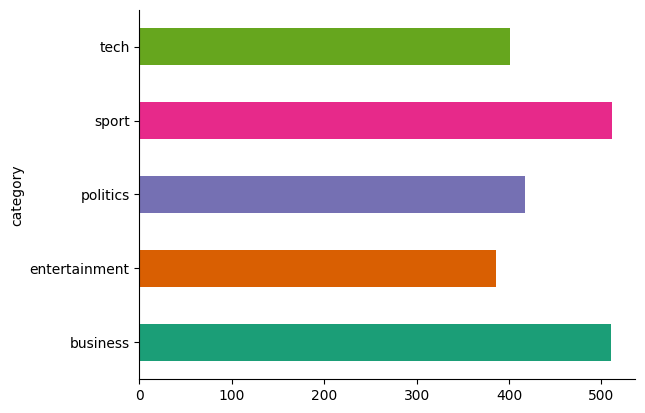

In [ ]:
df.groupby('category').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

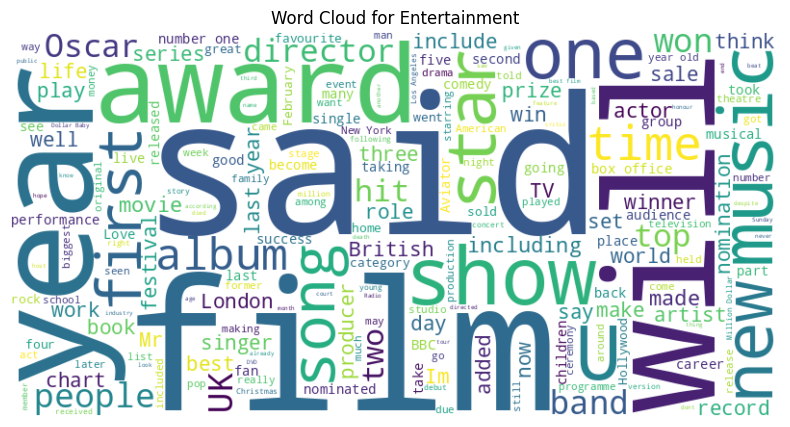

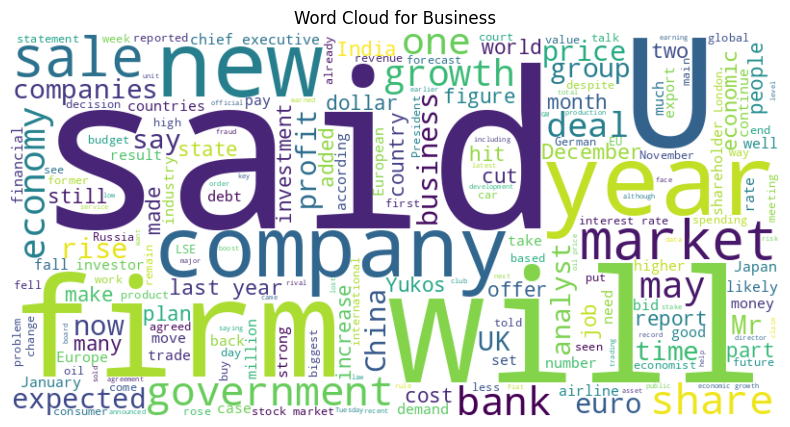

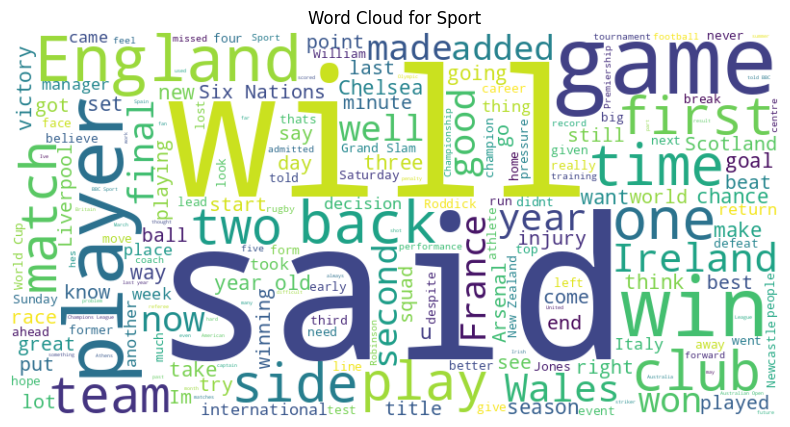

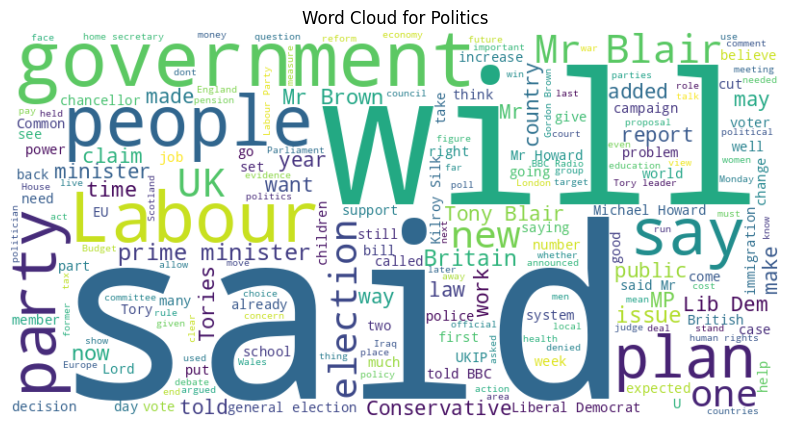

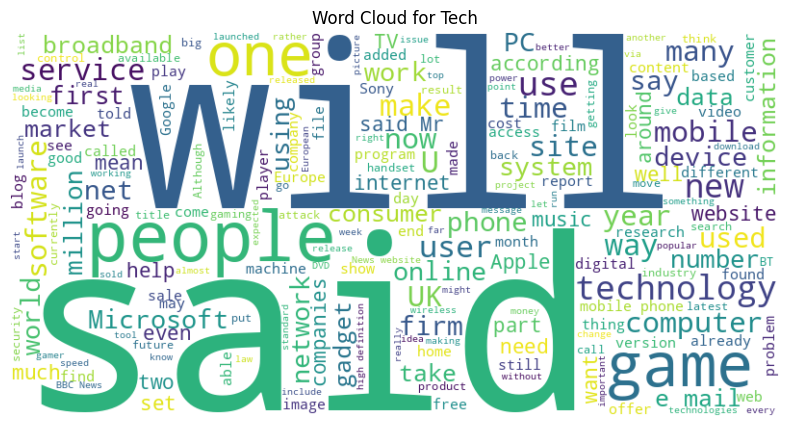

In [ ]:

for category in df['category'].unique():
    text = " ".join(df[df['category'] == category]['text'])
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

    plt.figure(figsize=(8, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(f"Word Cloud for {category.capitalize()}")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

In [ ]:
import os
os.environ["WANDB_DISABLED"] = "true"

## **Main Classifier**

This section builds a multi-class classifier to predict the top-level BBC news category (business, politics, sport, etc.) using the DistilBERT model. Though not part of the original HMLR subcategory challenge, it serves as an optional exploratory task or baseline model to validate text separability before subcategory classification.

In [ ]:

from sklearn.preprocessing import LabelEncoder
df['label'] = LabelEncoder().fit_transform(df['category'])


dataset = Dataset.from_pandas(df[['text', 'label']])


tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

def tokenize_fn(examples):
    return tokenizer(examples["text"], truncation=True, padding=True)

tokenized = dataset.map(tokenize_fn, batched=True)


tokenized = tokenized.train_test_split(test_size=0.2)

model = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=5)


training_args = TrainingArguments(
    output_dir="./results",

    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=2,
    weight_decay=0.01
)


trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized["train"],
    eval_dataset=tokenized["test"],
    tokenizer=tokenizer
)


trainer.train()

preds_output = trainer.predict(tokenized["test"])
preds = preds_output.predictions.argmax(axis=1)


print(classification_report(tokenized["test"]["label"], preds))

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Map:   0%|          | 0/2225 [00:00<?, ? examples/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
/tmp/ipython-input-11-2885465570.py:31: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss


              precision    recall  f1-score   support

           0       0.99      1.00      1.00       106
           1       0.99      1.00      0.99        77
           2       1.00      0.98      0.99        85
           3       1.00      1.00      1.00       100
           4       0.99      0.99      0.99        77

    accuracy                           0.99       445
   macro avg       0.99      0.99      0.99       445
weighted avg       0.99      0.99      0.99       445



## **Zero-Shot Subcategory Classification Using BART**
This section uses a zero-shot classification approach to assign more granular subcategories to existing top-level categories (e.g., business, entertainment, politics) in the BBC news dataset.

Leveraging the facebook/bart-large-mnli model from Hugging Face’s Transformers library, each article is evaluated against a custom list of subcategories specific to its main category.

The top-scoring subcategory is selected per article without any model fine-tuning. The results are presented by showing samples from the top, middle, and bottom of the dataset.

In [ ]:

device = 0 if torch.cuda.is_available() else -1
print("Using device:", "cuda" if device == 0 else "cpu")

zero_shot_clf = pipeline("zero-shot-classification", model="facebook/bart-large-mnli", device=device)


subcat_labels = {
    'business': ['stock market', 'company news', 'mergers and acquisitions', 'finance', 'startups', 'economic policy'],
    'entertainment': ['cinema', 'theatre', 'music', 'literature', 'celebrity', 'TV shows', 'film industry'],
    'sport': ['football', 'cricket', 'Olympics', 'tennis', 'rugby', 'athletics', 'golf', 'boxing', 'motorsport'],
    'politics': ['elections', 'government policy', 'parliament', 'international relations', 'political debate', 'leaders'],
    'tech': ['gadgets', 'AI', 'software', 'cybersecurity', 'innovation', 'mobile technology', 'robotics']
}

df['subcategory_zs'] = None


subset_df = df[df['category'].isin(subcat_labels.keys())].copy()


for idx, row in tqdm(subset_df.iterrows(), total=len(subset_df), desc="Classifying subcategories"):
    text = row['text'][:512]  # Truncate for speed
    candidate_labels = subcat_labels[row['category']]
    result = zero_shot_clf(text, candidate_labels=candidate_labels)
    df.at[idx, 'subcategory_zs'] = result['labels'][0]


subset_to_display = pd.concat([
    df[['category', 'subcategory_zs']].dropna().head(3),
    df[['category', 'subcategory_zs']].dropna().iloc[len(df)//2:len(df)//2+3],
    df[['category', 'subcategory_zs']].dropna().tail(3)
])
print("\nSample Zero-Shot Predictions (Head, Middle, Tail):")
print(subset_to_display)


Using device: cuda


Device set to use cuda:0
Classifying subcategories: 100%|██████████| 2225/2225 [09:22<00:00,  3.96it/s]


Sample Zero-Shot Predictions (Head, Middle, Tail):
           category     subcategory_zs
0     entertainment              music
1     entertainment              music
2     entertainment              music
1112          sport              rugby
1113          sport              rugby
1114          sport              rugby
2222           tech         innovation
2223           tech  mobile technology
2224           tech      cybersecurity


In [ ]:
df.to_csv("/content/bbc_datasetnew.csv", index=False)


In [ ]:
df.head()

,category,text,label,subcategory_zs
0,entertainment,Musicians to tackle US red tape Musicians gro...,1,music
1,entertainment,"U2s desire to be number one U2, who have won ...",1,music
2,entertainment,Rocker Doherty in on-stage fight Rock singer ...,1,music
3,entertainment,Snicket tops US box office chart The film ada...,1,cinema
4,entertainment,"Oceans Twelve raids box office Oceans Twelve,...",1,cinema



### Subcategory Classification: Evaluation Metrics

Manual reveiw was used to validate the accuracy of subcategory classification


In [ ]:
eval_sample_df = df.dropna(subset=['subcategory_zs']).sample(n=5, random_state=42).copy()


eval_sample_df['subcategory_true'] = None


for idx, row in eval_sample_df.iterrows():
    print(f"\n ARTICLE {idx}")
    print("Main Category:", row['category'])
    print("Predicted Subcategory:", row['subcategory_zs'])
    print("Text Preview:\n", row['text'][:500])  # Show preview

    try:
        true_label = input("Enter the TRUE subcategory (press Enter to skip): ").strip()
    except EOFError:
        print("\nInput stream closed. Skipping manual input.")
        true_label = "" # Assign empty string if input stream is closed

    # Update the eval_sample_df DataFrame with the manually entered label
    if true_label:
        eval_sample_df.at[idx, 'subcategory_true'] = true_label
        print(f" Stored label '{true_label}' for ARTICLE {idx}")
    else:
        print("Skipped...")

print("\nManual labeling for the sample is complete. The results are stored in 'eval_sample_df'.")



 ARTICLE 414
Main Category: business
Predicted Subcategory: finance
Text Preview:
 China now top trader with Japan  China overtook the US to become Japans biggest trading partner in 2004, according to numbers released by Japans Finance Ministry on Wednesday.  China accounted for 20.1 of Japans trade in 2004, compared with 18.6 for the US. In 2003, the US was ahead with 20.5 and China came second with 19.2. The change highlights Chinas growing importance as an economic powerhouse. In 2004, Japans imports from and exports to China and Hong Kong added up to 22,201bn yen 214.6bnÂ1
Enter the TRUE subcategory (press Enter to skip): true 
 Stored label 'true' for ARTICLE 414

 ARTICLE 420
Main Category: business
Predicted Subcategory: finance
Text Preview:
 Bush budget seeks deep cutbacks  President Bush has presented his 2006 budget, cutting domestic spending in a bid to lower a record deficit projected to peak at 427bn Â230bn this year.  The 2.58 trillion Â1.38 trillion budget submitted to

## 🧾 Subcategory Classification: Display predicted 5 Categories

In [ ]:

grouped_samples = (
    df.dropna(subset=['subcategory_zs'])
      .groupby('category', group_keys=False)
      .apply(lambda g: g[['category', 'subcategory_zs']].head(5))
)

print("First 5 Subcategory Predictions per Category:")
display(grouped_samples)


📌 First 5 Subcategory Predictions per Category:


/tmp/ipython-input-17-2411669970.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g[['category', 'subcategory_zs']].head(5))


,category,subcategory_zs
386,business,company news
387,business,company news
388,business,stock market
389,business,stock market
390,business,company news
0,entertainment,music
1,entertainment,music
2,entertainment,music
3,entertainment,cinema
4,entertainment,cinema


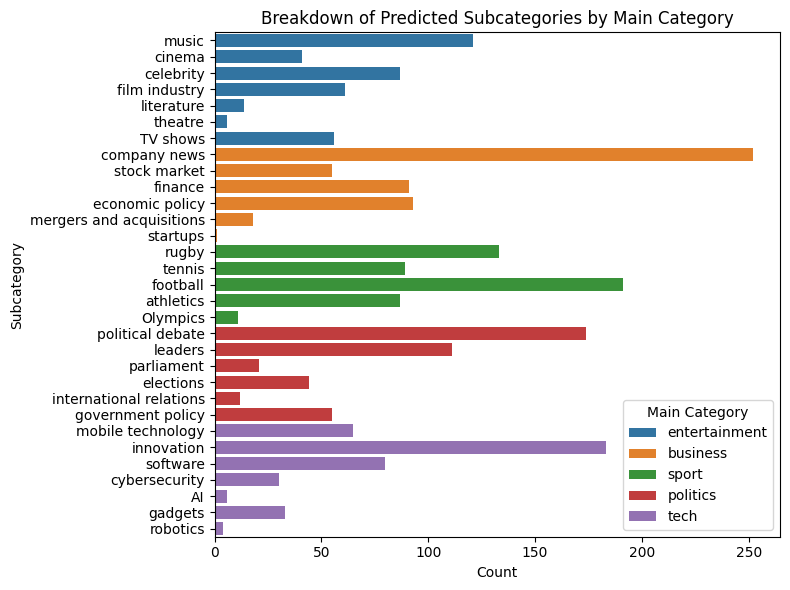

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, y='subcategory_zs', hue='category')
plt.title("Breakdown of Predicted Subcategories by Main Category")
plt.xlabel("Count")
plt.ylabel("Subcategory")
plt.legend(title="Main Category")
plt.tight_layout()
plt.show()

## **Named Entity Recognition(NER)**
it uses spaCy's transformer model to extract named persons from the dataset and assigns likely professions (e.g., Politician, Musician, Athlete) based on contextual keyword matching. The results are grouped by job category for analysis.

In [ ]:
import spacy
nlp = spacy.load("en_core_web_trf")


ner_df = df[df['category'].isin(['entertainment', 'politics', 'sport'])].sample(100, random_state=42).copy()

job_titles = {
    'Politician': ['MP', 'minister', 'senator', 'politician', 'parliamentarian'],
    'Musician': ['singer', 'musician', 'band', 'rapper', 'composer'],
    'TV/Film Personality': ['actor', 'actress', 'film star', 'TV host', 'director', 'producer'],
    'Writer': ['author', 'writer', 'novelist', 'journalist'],
    'Athlete': ['athlete', 'footballer', 'cricketer', 'tennis player', 'runner', 'sprinter', 'boxer', 'golfer', 'rugby player', 'cyclist']
}

def extract_spacy_entities(text):
    doc = nlp(text)
    return [ent.text for ent in doc.ents if ent.label_ == "PERSON"]

def infer_job(text, person_name):
    if len(person_name.split()) < 2:
        return "Unknown"

    for title, keywords in job_titles.items():
        for keyword in keywords:
            pattern = rf"\b{re.escape(person_name)}\b.*?\b{keyword}\b|\b{keyword}\b.*?\b{re.escape(person_name)}\b"
            if re.search(pattern, text, re.IGNORECASE):
                return title
    return "Unknown"


ner_results = []

for _, row in tqdm(ner_df.iterrows(), total=len(ner_df), desc="Extracting named entities"):
    people = extract_spacy_entities(row['text'])
    for name in people:
        job = infer_job(row['text'], name)
        ner_results.append({
            'name': name,
            'job': job,
            'category': row['category']
        })

ner_results_df = pd.DataFrame(ner_results)


media_df = ner_results_df[ner_results_df['job'] != 'Unknown'].copy()


media_df = media_df.drop_duplicates(subset=['name', 'job'])


media_df = media_df[['name', 'job', 'category']].sort_values(by='job')

grouped = media_df.groupby('job')

for job, group in grouped:
    print(f"\n📋 {job} ({len(group)} entries):")
    display(group.reset_index(drop=True))

Extracting named entities: 100%|██████████| 100/100 [00:40<00:00,  2.48it/s]


📋 Athlete (8 entries):


,name,job,category
0,Brian McFadden,Athlete,entertainment
1,Franz Ferdinand,Athlete,entertainment
2,Destinys Child,Athlete,entertainment
3,Liz Yelling,Athlete,sport
4,Delta Goodrem,Athlete,entertainment
5,Paula Radcliffe,Athlete,sport
6,Lil Wayne,Athlete,entertainment
7,Hugh Richards,Athlete,sport



📋 Musician (77 entries):


,name,job,category
0,Obie Trice,Musician,entertainment
1,Harry Belafonte,Musician,entertainment
2,Sidney Poiter,Musician,entertainment
3,Robbie Williams,Musician,entertainment
4,PJ Harvey,Musician,entertainment
...,...,...,...
72,Kurt Cobain,Musician,entertainment
73,Frances Bean,Musician,entertainment
74,Rand Rubin,Musician,entertainment
75,Kristin King,Musician,entertainment


...

,name,job,category
0,Ian McCartney,Politician,politics
1,Bernie Grant,Politician,politics
2,Paul Boateng,Politician,politics
3,Keith Vaz,Politician,politics
4,Diane Abbot,Politician,politics
...,...,...,...
71,Guy Mansfield QC,Politician,politics
72,Gerry Conlon,Politician,politics
73,Tony Hunter,Politician,politics
74,Robert Tapsfield,Politician,politics



📋 TV/Film Personality (64 entries):


,name,job,category
0,Bernardo Bertoluccis Last Tango,TV/Film Personality,entertainment
1,George Raft,TV/Film Personality,entertainment
2,Budd Schulberg,TV/Film Personality,entertainment
3,Shirley MacLaine,TV/Film Personality,entertainment
4,Don Corleone,TV/Film Personality,entertainment
...,...,...,...
59,Arsene Wenger,TV/Film Personality,sport
60,Keith Edelman,TV/Film Personality,sport
61,Michael Howard,TV/Film Personality,politics
62,Jonny Wilkinson,TV/Film Personality,sport



📋 Writer (5 entries):


,name,job,category
0,Stevie Wonder,Writer,entertainment
1,John Lennon,Writer,entertainment
2,Black America,Writer,entertainment
3,Rob Partridge,Writer,entertainment
4,Bob Marley,Writer,entertainment


### Evaluation
This block evaluates how accurately the inferred professions (e.g., Politician, Musician, Athlete) match known ground truth labels for named entities extracted from BBC articles. It compares predicted vs. actual job roles using classification metrics such as precision, recall, F1-score, and overall accuracy.

In [ ]:
from sklearn.metrics import classification_report, accuracy_score

ground_truth = pd.DataFrame([
    {"name": "Tony Blair", "true_job": "Politician"},
    {"name": "George Raft", "true_job": "TV/Film Personality"},
    {"name": "Ian McCartney", "true_job": "Politician"},
    {"name": "David Beckham", "true_job": "Athlete"},
    {"name": "Elton John", "true_job": "Musician"},
    {"name": "Liz Yelling", "true_job": "Athlete"},
    {"name": "Emma Watson", "true_job": "TV/Film Personality"},
    {"name": "JK Rowling", "true_job": "Writer"},
    {"name": "George Bush", "true_job": "Politician"},
    {"name": "Lil Wayne", "true_job": "Musician"},
    {"name": "Shirley MacLaine", "true_job": "TV/Film Personality"},
    {"name": "Paul Boateng", "true_job": "Politician"},
    {"name": "50 Cent", "true_job": "Musician"},
    {"name": "Roger Federer", "true_job": "Athlete"},
    {"name": "Budd Schulberg", "true_job": "TV/Film Personality"},
    {"name": "Bernie Grant", "true_job": "Politician"},
    {"name": "Paula Radcliffe", "true_job": "Athlete"},
    {"name": "Paul Boateng", "true_job": "Politician"},
    {"name": "Don Corleone", "true_job": "TV/Film Personality"},
    {"name": "Diane Abbot", "true_job": "Politician"}
])

eval_df = pd.merge(media_df, ground_truth, on="name", how="inner")

y_true = eval_df["true_job"]
y_pred = eval_df["job"]


print("Entity Classification Evaluation:")
print(classification_report(y_true, y_pred))
print("Accuracy Score:", accuracy_score(y_true, y_pred))


Entity Classification Evaluation:
                     precision    recall  f1-score   support

            Athlete       0.67      1.00      0.80         2
           Musician       1.00      0.50      0.67         2
         Politician       1.00      0.86      0.92         7
TV/Film Personality       0.80      1.00      0.89         4

           accuracy                           0.87        15
          macro avg       0.87      0.84      0.82        15
       weighted avg       0.90      0.87      0.86        15

Accuracy Score: 0.8666666666666667


## **April Event Summarisation**
This section extracts and summarizes news articles that mention "April" across all available categories (e.g., politics, business, entertainment).
For each category, up to three representative articles are selected and passed through a pre-trained summarization model (facebook/bart-large-cnn) using the Hugging Face pipeline.

The resulting summaries help provide a concise overview of events or discussions scheduled or reported in April, without requiring model fine-tuning or additional training.

In [ ]:
april_df = (
    df[df['text'].str.contains(r'\bApril\b', case=False, na=False)]
    .groupby('category', group_keys=False)
    .apply(lambda x: x.head(3))
    .reset_index(drop=True)
)

summarizer = pipeline("summarization", model="facebook/bart-large-cnn", device=0 if torch.cuda.is_available() else -1)


def summarize_article(text):
    max_len = 1024
    text = text[:max_len]
    summary = summarizer(text, max_length=100, min_length=30, do_sample=False)[0]['summary_text']
    return summary

april_df['summary'] = april_df['text'].apply(summarize_article)


print(april_df[['category', 'summary']])


/tmp/ipython-input-23-2307835514.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.head(3))
Device set to use cuda:0


         category                                            summary
0        business  Move came after the US lifted a trade ban to r...
1        business  SN to buy 37.5% of Indias United Breweries in ...
2        business  China is struggling to increase energy supplie...
3   entertainment  Pete Doherty involved in on-stage fight with g...
4   entertainment  The award was voted for by listeners of Virgin...
5   entertainment  The first Academy Awards were handed out in 19...
6        politics  Brown to freeze petrol duty increases, fund a ...
7        politics  Five public sector unions will hold private ta...
8        politics  Five public sector unions met Deputy Prime Min...
9           sport  Justine Henin-Hardenne lost to Elena Dementiev...
10          sport  Munsters Heineken Cup quarter-final tie agains...
11          sport  Radcliffe will compete in the Flora London Mar...
12           tech  New Yorker William Trowbridge and Texan Michae...
13           tech  New Yorker Will

### Evaluation of Sumaaries
 Evaluation of April Event Summaries Using BERTScore and ROUGE

It evaluates the quality of automatically generated summaries for articles mentioning April. Using manually created reference summaries, the evaluation measures:

BERTScore: to assess semantic similarity between generated and reference texts

ROUGE: to measure word overlap and structural similarity

These metrics provide insight into how well the model captures the key information in a concise and meaningful way.

In [ ]:

april_df['reference'] = [
    "The prime minister announced new reforms in April during a policy meeting.",
    "A global tech firm launched its latest smartphone series in early April.",
    "Several athletes broke records in an April sports championship event.",
    "Climate leaders met in April to discuss emission targets.",
    "The theatre industry resumed performances under April health guidelines.",
    "In April, the education ministry introduced new learning policies."
] + [""] * (len(april_df) - 6)

valid_df = april_df[april_df['reference'].str.len() > 0].copy()


from bert_score import score

P, R, F1 = score(valid_df['summary'].tolist(), valid_df['reference'].tolist(), lang="en", verbose=True)
valid_df['bertscore_f1'] = F1.tolist()


try:
    from rouge_score import rouge_scorer
    scorer = rouge_scorer.RougeScorer(['rouge1', 'rougeL'], use_stemmer=True)
    rouge1_scores = []
    rougeL_scores = []
    for ref, pred in zip(valid_df['reference'], valid_df['summary']):
        scores = scorer.score(ref, pred)
        rouge1_scores.append(scores['rouge1'].fmeasure)
        rougeL_scores.append(scores['rougeL'].fmeasure)

    valid_df['rouge1_f1'] = rouge1_scores
    valid_df['rougeL_f1'] = rougeL_scores
except ImportError:
    print("Optional: Install `rouge-score` with `pip install rouge-score` for ROUGE evaluation.")


print(valid_df[['category', 'summary', 'reference', 'bertscore_f1'] + ([ 'rouge1_f1', 'rougeL_f1'] if 'rouge1_f1' in valid_df else [])])


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


calculating scores...
computing bert embedding.


  0%|          | 0/1 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/1 [00:00<?, ?it/s]

done in 0.17 seconds, 35.32 sentences/sec
Optional: Install `rouge-score` with `pip install rouge-score` for ROUGE evaluation.
        category                                            summary  \
0       business  Move came after the US lifted a trade ban to r...   
1       business  SN to buy 37.5% of Indias United Breweries in ...   
2       business  China is struggling to increase energy supplie...   
3  entertainment  Pete Doherty involved in on-stage fight with g...   
4  entertainment  The award was voted for by listeners of Virgin...   
5  entertainment  The first Academy Awards were handed out in 19...   

                                           reference  bertscore_f1  
0  The prime minister announced new reforms in Ap...      0.847419  
1  A global tech firm launched its latest smartph...      0.816732  
2  Several athletes broke records in an April spo...      0.841293  
3  Climate leaders met in April to discuss emissi...      0.831438  
4  The theatre industry resume

### Filtering April event
 We filtered articles that mention "April" and contain event-related keywords such as "scheduled", "held", or "conference".
The goal was to extract and summarize documents referring to events that occurred or were planned in April, grouped by category (e.g. sport, business, entertainment).

A transformer-based summarization model (facebook/bart-large-cnn) was used to generate concise summaries of each article.
The results were verified by highlighting the occurrence of "April" in the original text to confirm relevance.

In [ ]:

event_keywords = [
    'scheduled', 'held', 'announced', 'took place', 'takes place','April'
    'starts', 'events', 'during','date','begins', 'launch', 'final', 'match', 'conference', 'ceremony', 'summit'
]


april_df = df[df['text'].str.contains(r'\bApril\b', case=False, na=False)].copy()
april_df = april_df[april_df['text'].str.contains('|'.join(event_keywords), case=False, na=False)]

april_df = (
    april_df.groupby('category', group_keys=False)
    .apply(lambda x: x.head(3))
    .reset_index(drop=True)
)

summarizer = pipeline("summarization", model="facebook/bart-large-cnn", device=0 if torch.cuda.is_available() else -1)

def summarize_article(text):
    max_len = 1024
    text = text[:max_len]
    summary = summarizer(text, max_length=100, min_length=30, do_sample=False)[0]['summary_text']
    return summary

april_df['summary'] = april_df['text'].apply(summarize_article)


for idx, row in april_df.iterrows():
    print(f"\n Article {idx + 1}")
    print(f"Category: {row['category']}")


    highlighted_text = re.sub(r"(April)", r"👉 \1 👈", row['text'], flags=re.IGNORECASE)

    print("Original Text Snippet (highlighted):\n")
    print(highlighted_text[:1000])
    print("\n Summary:\n")
    print(row['summary'])
    print("=" * 100)


/tmp/ipython-input-22-1313333568.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.head(3))
Device set to use cuda:0



 Article 1
Category: business
Original Text Snippet (highlighted):

Strong quarterly growth for Nike  Nike has reported its best second-quarter earnings, helped by strong demand for its athletic shoes and Converse sneakers.  The global sports giant said it posted a profit of 261.9m Â135.6m, for the three months to 30 November, up from 179.1m in the same period last year. Revenues increased 11 to 3.1bn, from 2.8bn for the same period in 2003. Nike, whose products are endorsed by Tiger Woods among other sports stars, said demand continues to grow. The results came after a strong first quarter of the year for the firm based in Beaverton, Oregon.  Philip Knight, chairman and chief executive, said Nikes second-quarter revenues and earnings per share reached all-time high levels as a result of solid performance across our global portfolio. Our businesses in the United States and emerging markets such as China, Russia and Turkey, combined with favourable European exchange rates, helped drive


## Bias/Limitations

This project uses the **BBC full-text news dataset**, originally distributed in a ZIP format and converted to CSV (`bbc_dataset.csv`).

- **Zero-shot classifier bias**: Subcategory classification relies on pre-trained zero-shot models (`bart-large-mnli`), which may carry cultural or topical biases from their training data (e.g., over-represented Western media).
- **NER model bias**: Media personalities may be misclassified based on sentence context, especially if not explicitly associated with their profession.
- **Summarization bias**: BART-based summarizers may omit critical info, especially when "April" occurs at the end of the article, due to input truncation (limited to 1024 tokens).

